<a href="https://colab.research.google.com/github/joblingjack/Visual-Analytics/blob/main/Jobling_06_DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization (Part 1)

In R, the clear winner when it comes to data visualization packages is ggplot2 (part of the Tidyverse of packages). In Python, it is far less clear which package is "best". You can use:

*   plotnine (provides R-like functionality)
*   matplotlib

I have already installed the plotnine package, but have provided the code for installation below (commented out) in case you need it.

In [1]:
#!pip install plotnine

In the code below, we will 1) import the pyplot module from the popular matplotlib library and assign the alias plt 2) import the numpy library and assign an alias np and 3) import the pandas library and assign the alias pd.

1) **pyplot** provides a MATLAB-like interface for creating visualizations such as line plots, histograms, and scatter plots in Python.

2) **plotnine** is a Python implementation of the popular R package ggplot2 and designed to implement the grammar of graphics concept in Python, enabling users to create complex visualizations in a concise way.

Note: The asterisk (*) indicates that all functionalities (like classes, methods, and variables) within plotnine are imported into the current namespace.

In [2]:
# load our libraries
# notice that each library will have an alias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# note we use a little different syntax for access to a Python version of ggplot
# "*" means we will inmport all of the functionality of plotnine
from plotnine import *

##plotnine and ggplot2: Import datasets

**plotnine** allows us to use syntax nearly identical to R's ggplot2 syntax. This is provided by the "plotnine" package in Python.

Let's use two datasets from the "plotnine" package. These are the same *mtcars* and *diamonds* datasets that are included as default datasets in R. Load them with the code below.

Reminder:
***mtcars*** contains data on various characteristics of cars, including miles
per gallon, horsepower, weight, and more. The dataset was originally extracted from the 1974 Motor Trend US magazine and includes information on the performance and design of 32 different car models. ***diamonds*** contains information about the price and characteristics (such as cut, color, clarity, carat, etc.) of over 50,000 diamonds.

In addition, we will also use the iris dataset using the pandas *read_csv()* command from a url.

Reminder: ***iris*** contains information about three species of iris flowers (setosa, versicolor, and virginica), along with their measurements: sepal length, sepal width, petal length, and petal width.




In [3]:
from plotnine.data import mtcars
from plotnine.data import diamonds
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')

##EDA- Exploratory Data Analysis Begins...

Reminder: This is an approach to analyzing data sets to summarize their main characteristics, often using visual methods.


*   Understand the Structure of Data (info(), describe(), shape())
*   Detect Outliers and Anomalies
*   Check Assumptions
*   Visualize Relationships

EDA often focuses on understanding relationships between variables through visualizations like scatter plots, bar charts, and heatmaps.item




In [4]:
mtcars.shape

(32, 12)

In [5]:
mtcars.info()
mtcars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [6]:
#change data type to category and verify
#cyl: Number of cylinders: 4,6,8, vs:Engine: 0 = V-shaped, 1 = straight, am: Transmission: 0 = automatic, 1 = manual
mtcars['cyl'] = mtcars['cyl'].astype('category')
mtcars['vs'] = mtcars['vs'].astype('category')
mtcars['am'] = mtcars['am'].astype('category')

mtcars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   name    32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     int64   
 11  carb    32 non-null     int64   
dtypes: category(3), float64(5), int64(3), object(1)
memory usage: 2.8+ KB


In [7]:
print("Frequency and Relative Frequency for 'cyl':")
print(mtcars['cyl'].value_counts())
print(mtcars['cyl'].value_counts(normalize=True))
print("\nFrequency and Relative Frequency for 'vs':")
print(mtcars['vs'].value_counts())
print(mtcars['vs'].value_counts(normalize=True))
print("\nFrequency and Relative Frequency for 'am':")
print(mtcars['am'].value_counts())
print(mtcars['am'].value_counts(normalize=True))

Frequency and Relative Frequency for 'cyl':
cyl
8    14
4    11
6     7
Name: count, dtype: int64
cyl
8    0.43750
4    0.34375
6    0.21875
Name: proportion, dtype: float64

Frequency and Relative Frequency for 'vs':
vs
0    18
1    14
Name: count, dtype: int64
vs
0    0.5625
1    0.4375
Name: proportion, dtype: float64

Frequency and Relative Frequency for 'am':
am
0    19
1    13
Name: count, dtype: int64
am
0    0.59375
1    0.40625
Name: proportion, dtype: float64


⚡YOUR TURN: Start an EDA assessment of the ***diamonds*** data frame by using the info(), describe(), and shape commands.

⚡YOUR TURN: Start an EDA assessment of the ***iris*** data frame by using the info(), describe(), and shape commands

##Data Visualizations Using plotnine

###Scatterplots

Now we can make a sample scatterplot using ggplot2 syntax. Create a scatterplot from the ***mtcars*** data frame and use x = ***hp*** and y = ***mpg***.

This code generates a scatter plot where the ***hp*** (horsepower) is on the x-axis and the ***mpg*** (miles per gallon) is on the y-axis. Each point in the scatter plot represents a car from the ***mtcars*** dataset, and the plot helps to visualize how mpg varies with hp.

Hint: Don't forget to put the variable names in quotes (this is different than R syntax).

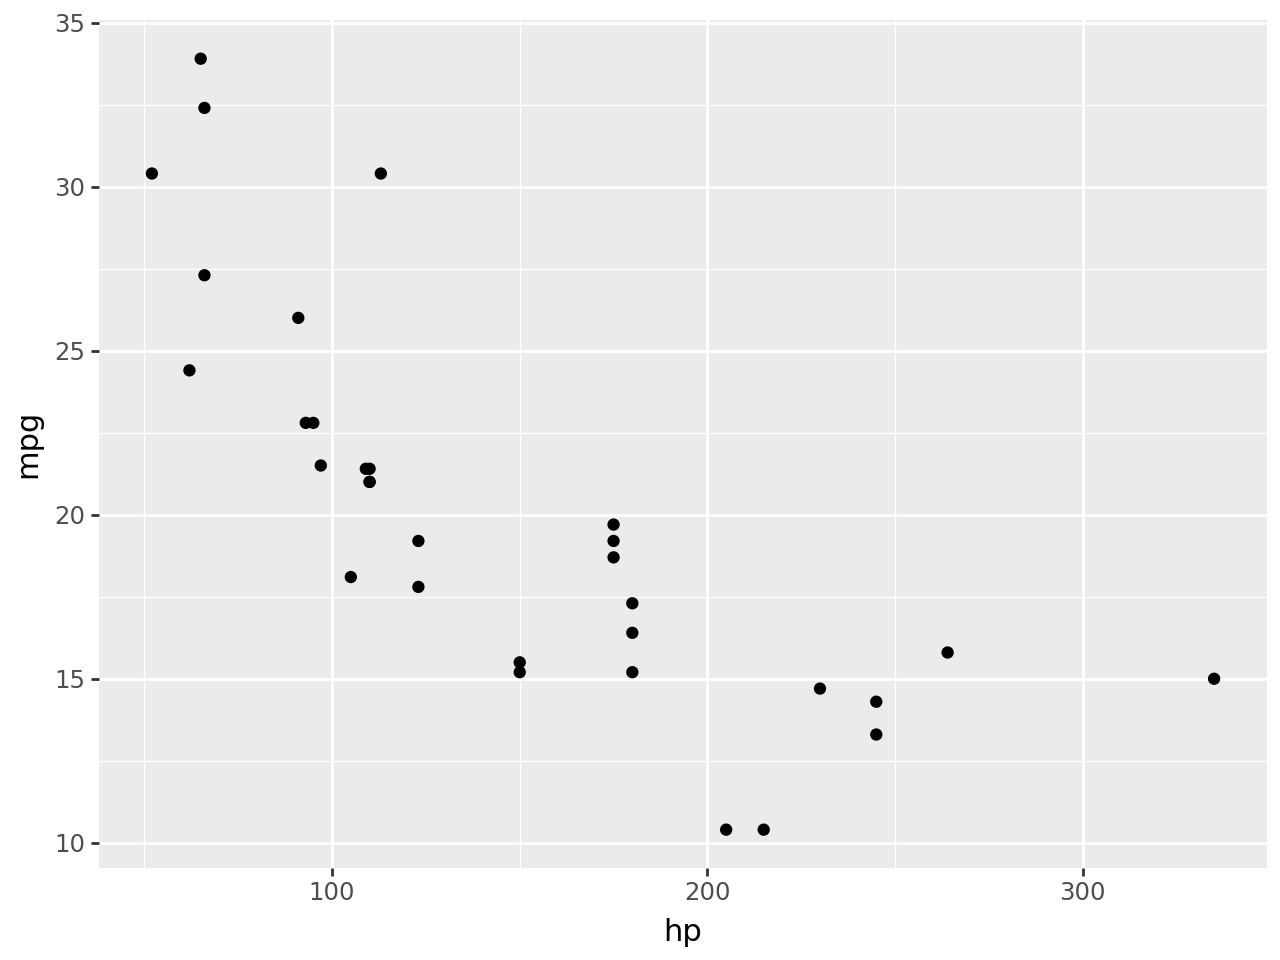

In [8]:
ggplot(mtcars, aes(x = "hp", y = "mpg")) + geom_point()

As we did in R, we can apply themes. In this case, theme_bw() stands for black and white theme. It provides a minimalistic look to the plot with a plain background and black grid lines. It removes the default gray background and replaces it with a white one, offering a clean and professional appearance.


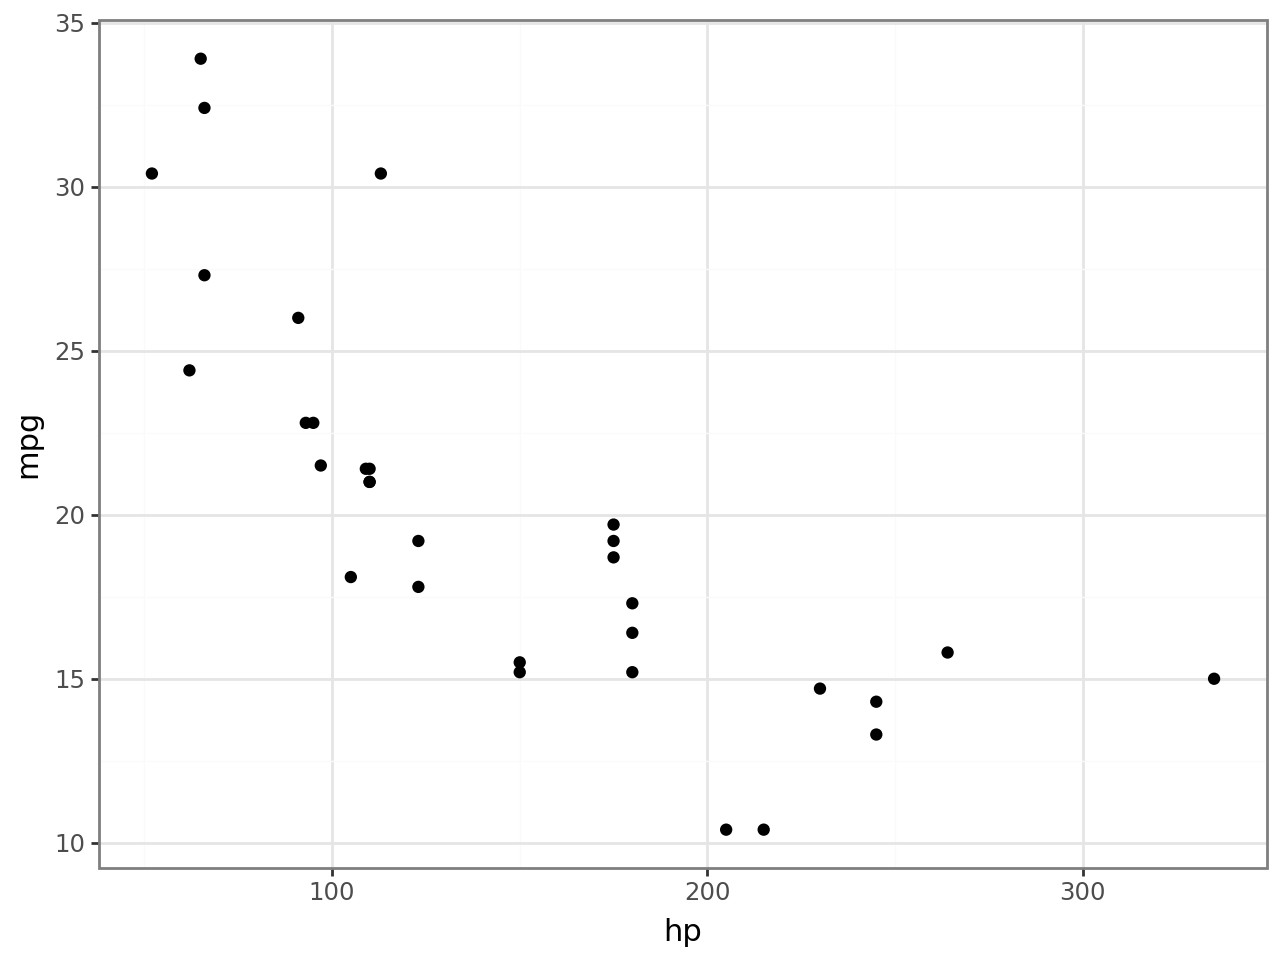

In [9]:
ggplot(mtcars, aes(x = "hp", y = "mpg")) + geom_point() + theme_bw()

⚡YOUR TURN: Create a scatterplot from the ***iris*** data frame and use x = ***sepal_length*** and y = ***petal_length*** using the black and white theme.

Let's try to subset

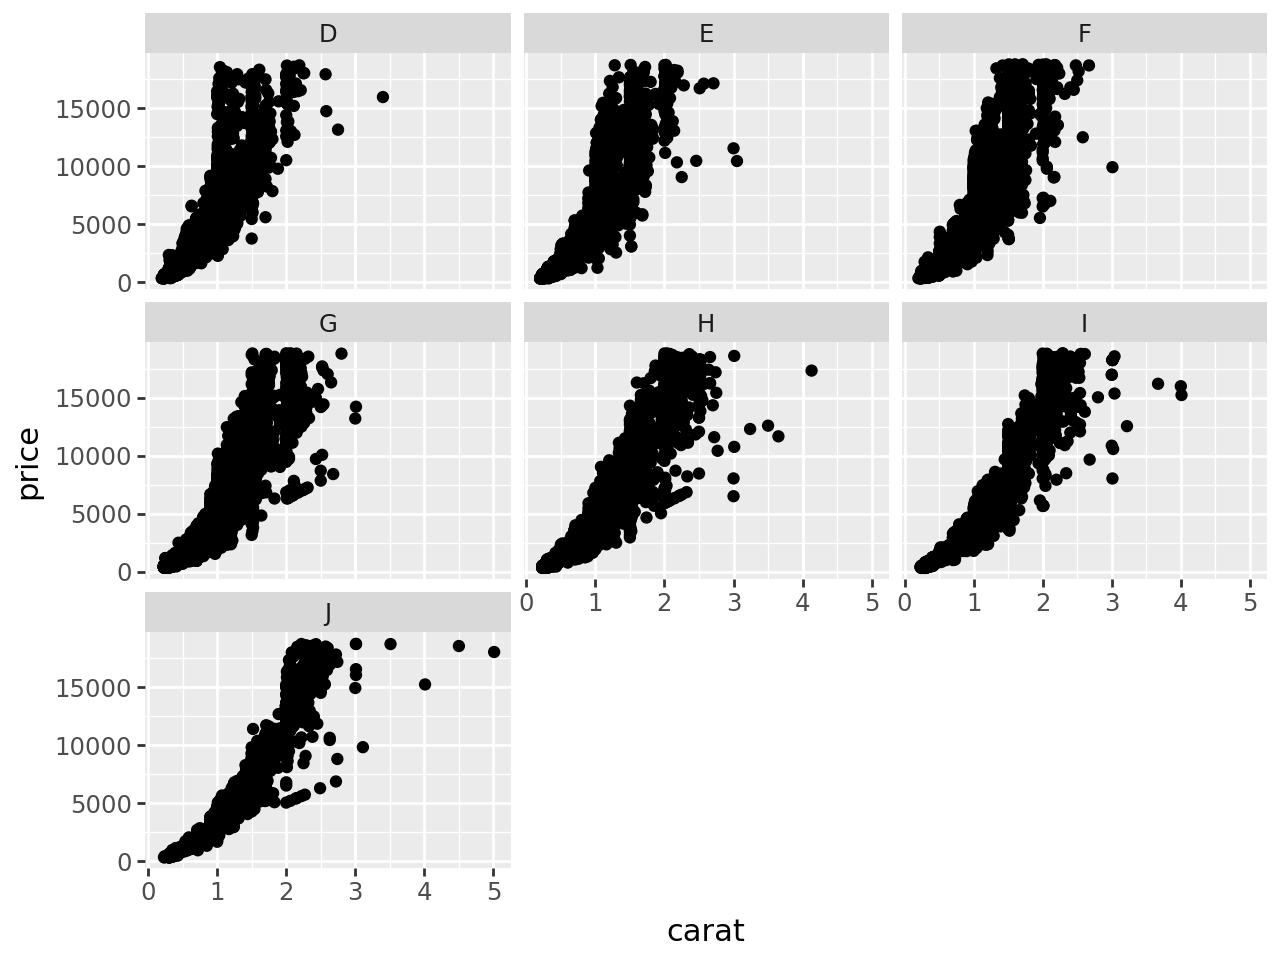

In [10]:
ggplot(diamonds, aes(x = "carat", y = "price")) + geom_point() + facet_wrap("color")

⚡YOUR TURN: Create a scatterplot from the ***iris*** data frame and use x = ***sepal_length*** and y = ***petal_lengt***h with a facet_wrap = species.

Here's another example. This time we look at a basic boxplot.

This is a little trickier than it probably should be. ggplot (and by association, plotnine) looks for both an x and a y variable to be defined for a boxplot. If we want just a single boxplot, we need to define a dummy variable for x. Here we just use x = 0.

Create a boxplot from the ***mtcars*** data set of the ***mpg*** variable.

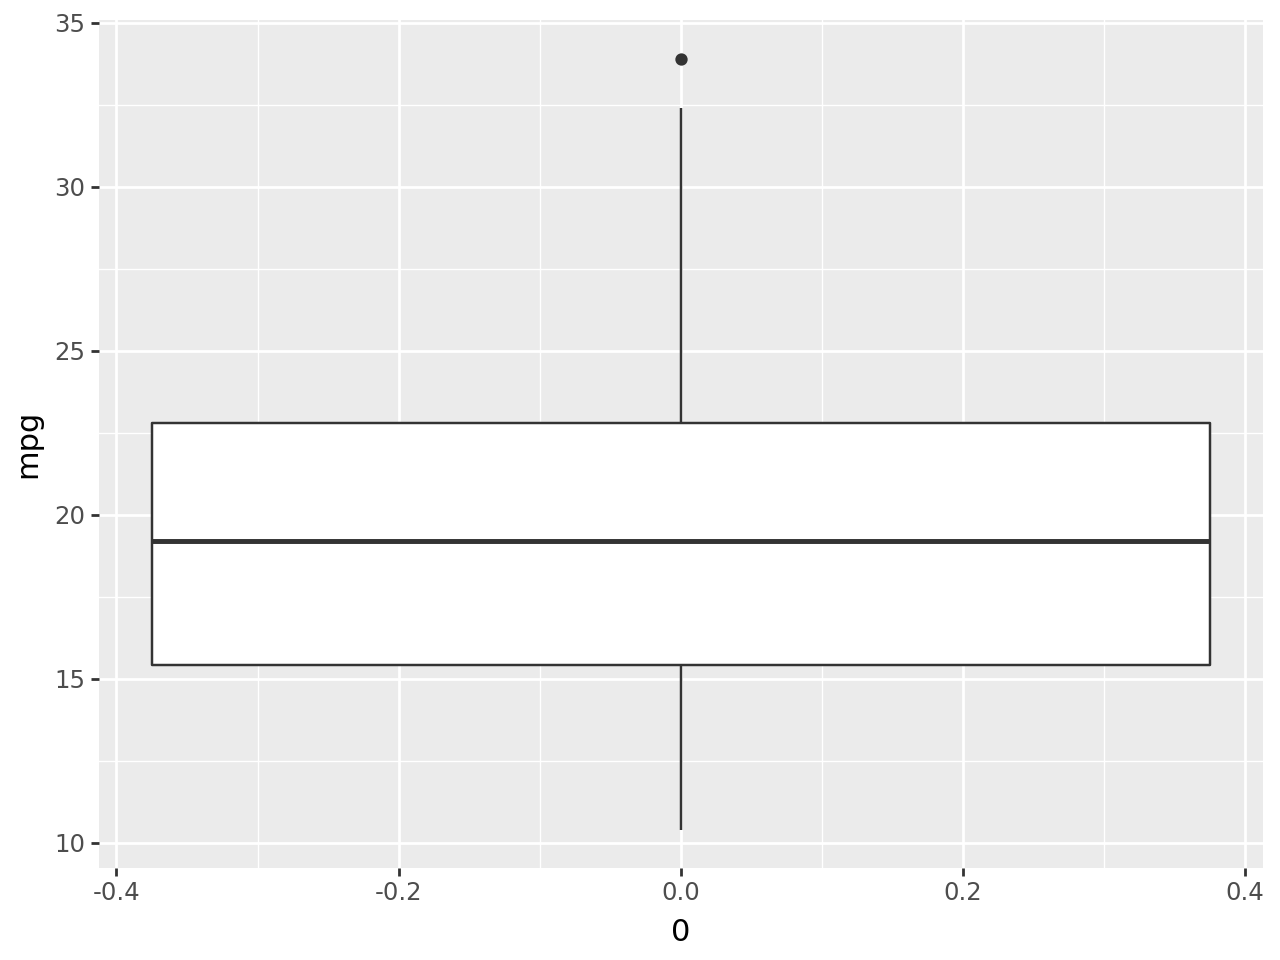

In [11]:
ggplot(mtcars, aes(x = 0, y = "mpg")) + geom_boxplot()
#notice the x=0

Next, let's look at ***mpg*** grouped by ***cyl***. We need the ***cyl*** variable to be treated like a factor (categorical) so we add "factor" to the variable name (inside the quotes).  

Create a boxplot from the ***mtcars*** data set of the ***mpg*** variable grouped by ***cyl*** variable and treat ***cyl*** variable as a factor data type.

In [12]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   name    32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     int64   
 11  carb    32 non-null     int64   
dtypes: category(3), float64(5), int64(3), object(1)
memory usage: 2.8+ KB


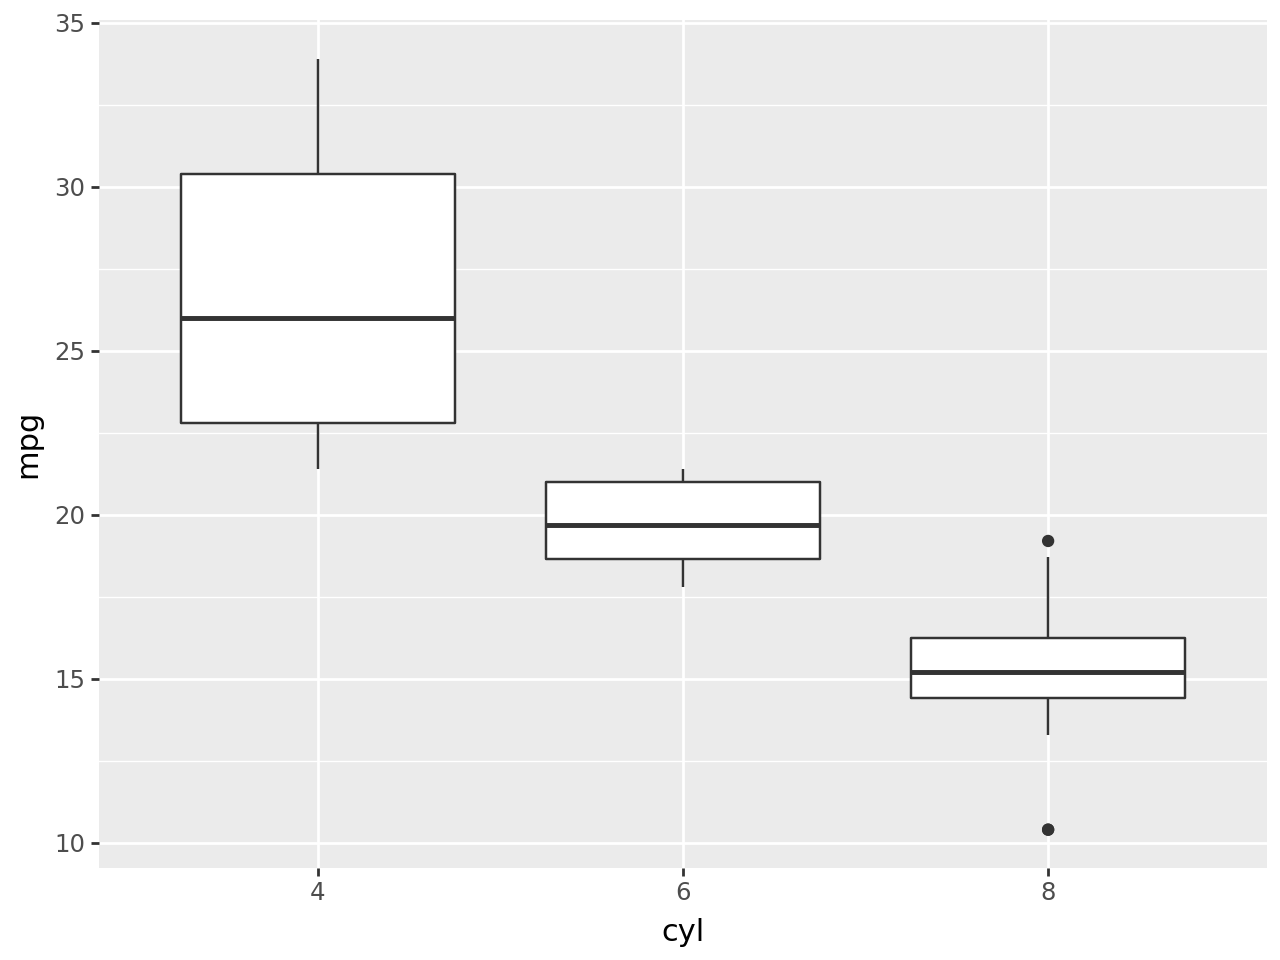

In [13]:
ggplot(mtcars, aes(x = "cyl", y = "mpg")) + geom_boxplot()

⚡YOUR TURN: Create a boxplot from the ***iris*** data frame and use x = 0 and y = ***petal_length***.

⚡YOUR TURN: Create a boxplot from the ***iris*** data frame of ***sepal_length*** grouped by ***species***.

### Histogram
Now let's look at histograms using the ggplot syntax.

Create a histogram from the ***mtcars*** data set of the ***mpg*** variable.

/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 6'. Pick better value with 'binwidth'.


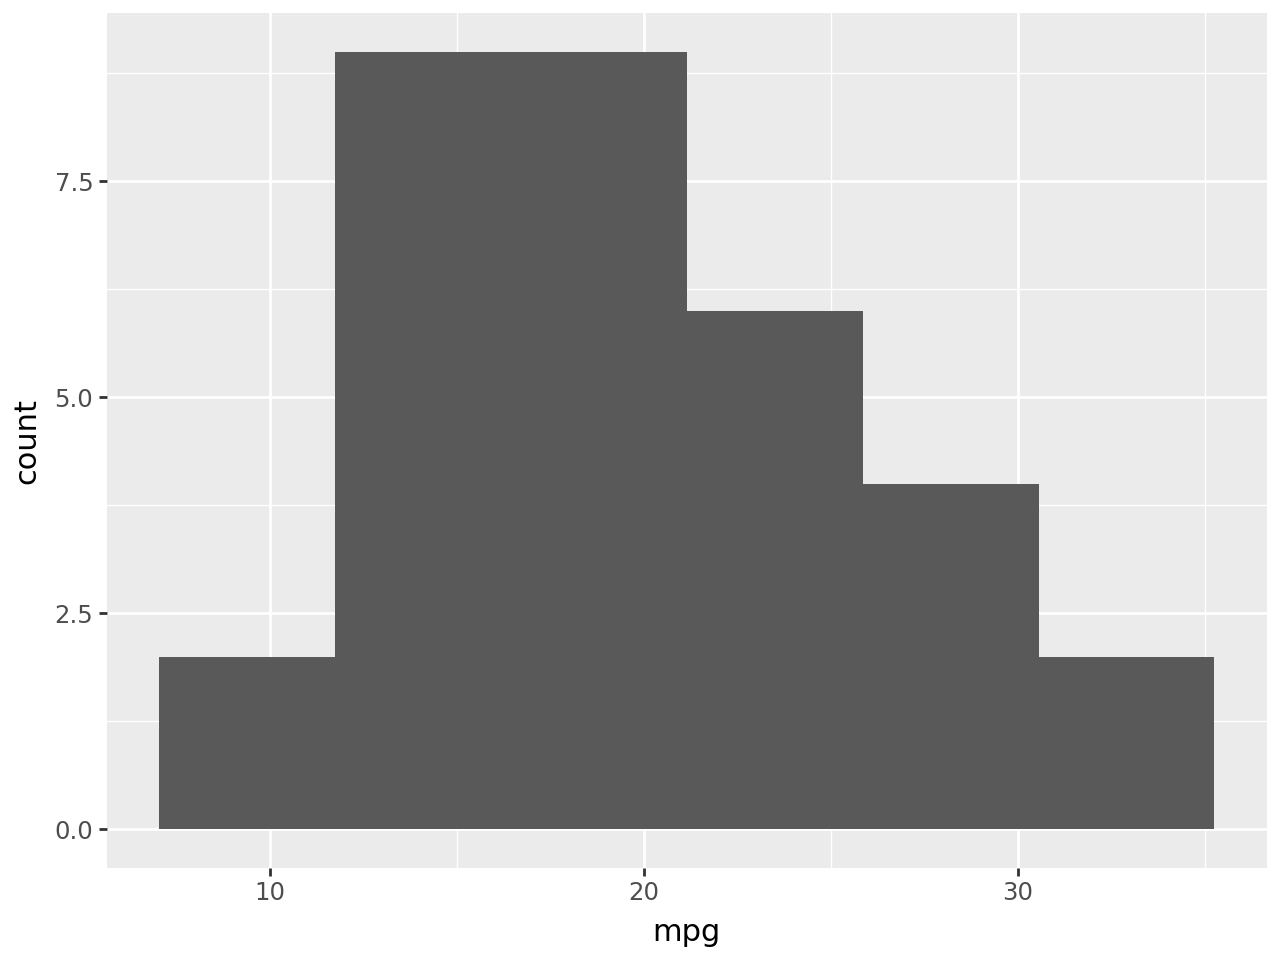

In [14]:
ggplot(mtcars, aes(x = "mpg")) + geom_histogram()

Here's another histogram, this time from the diamonds dataset.

Create a histogram from the ***diamonds*** data set of the ***price*** variable.

/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 80'. Pick better value with 'binwidth'.


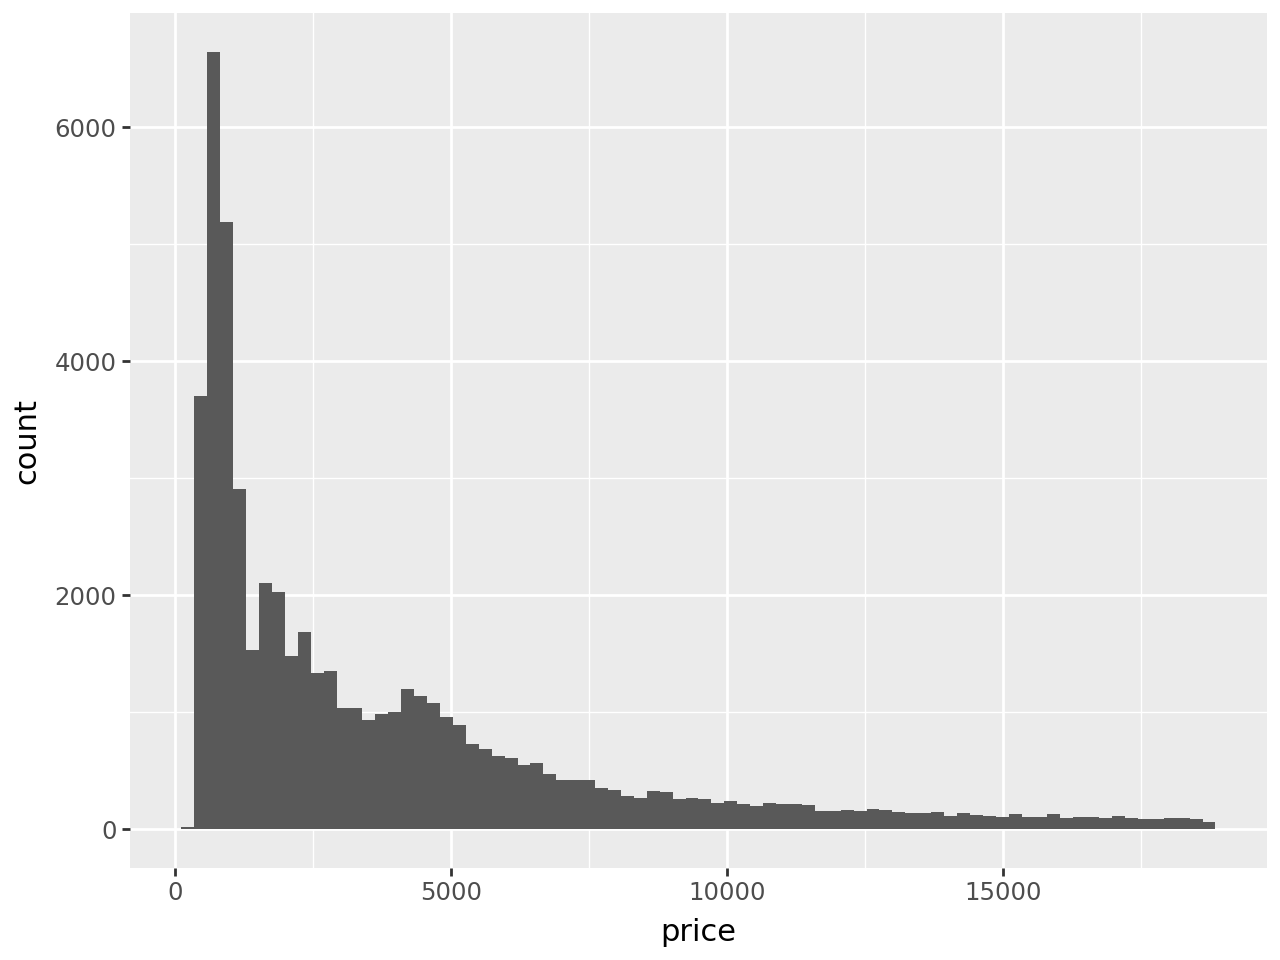

In [15]:
ggplot(diamonds, aes(x = "price")) + geom_histogram()

As we did in R, we can directly specify the number of bins.

Create a histogram from the ***diamonds*** data set of the ***price*** variable with the number of bins = 15.

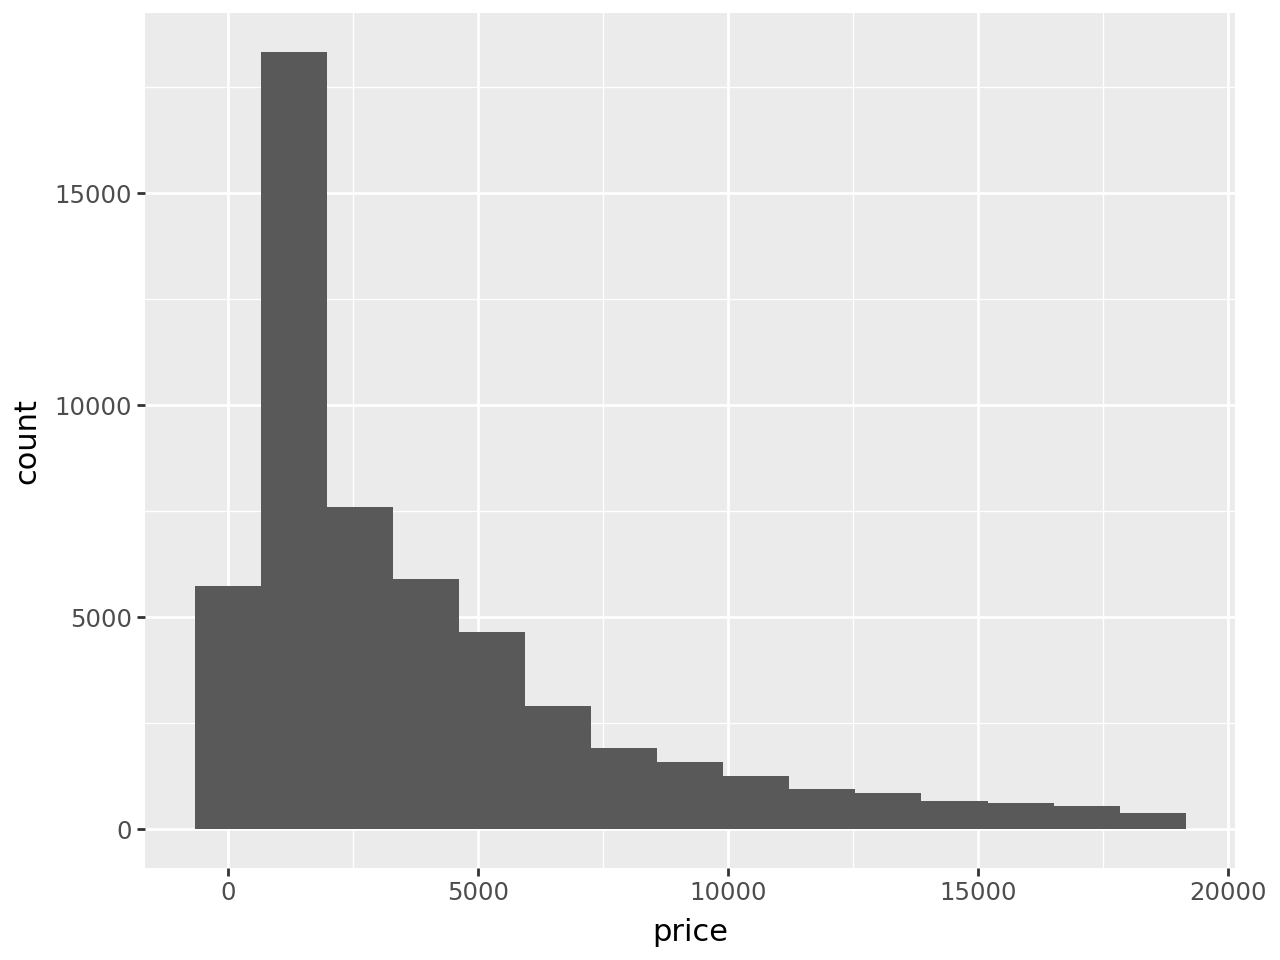

In [16]:
ggplot(diamonds, aes(x = "price")) + geom_histogram(bins = 15)

⚡YOUR TURN: Create a histogram from the ***iris*** data frame using ***sepal_length*** with default number of bins.

⚡YOUR TURN: Create a histogram from the ***iris*** data frame using ***sepal_length*** with bins = 10.

###Barplot

This chart looks better if we treat ***cyl*** as a categorical variable and use "factor" (as we did before for the boxplot). This chart shows a count of the number of vehicles in the dataset by ***cyl***.  

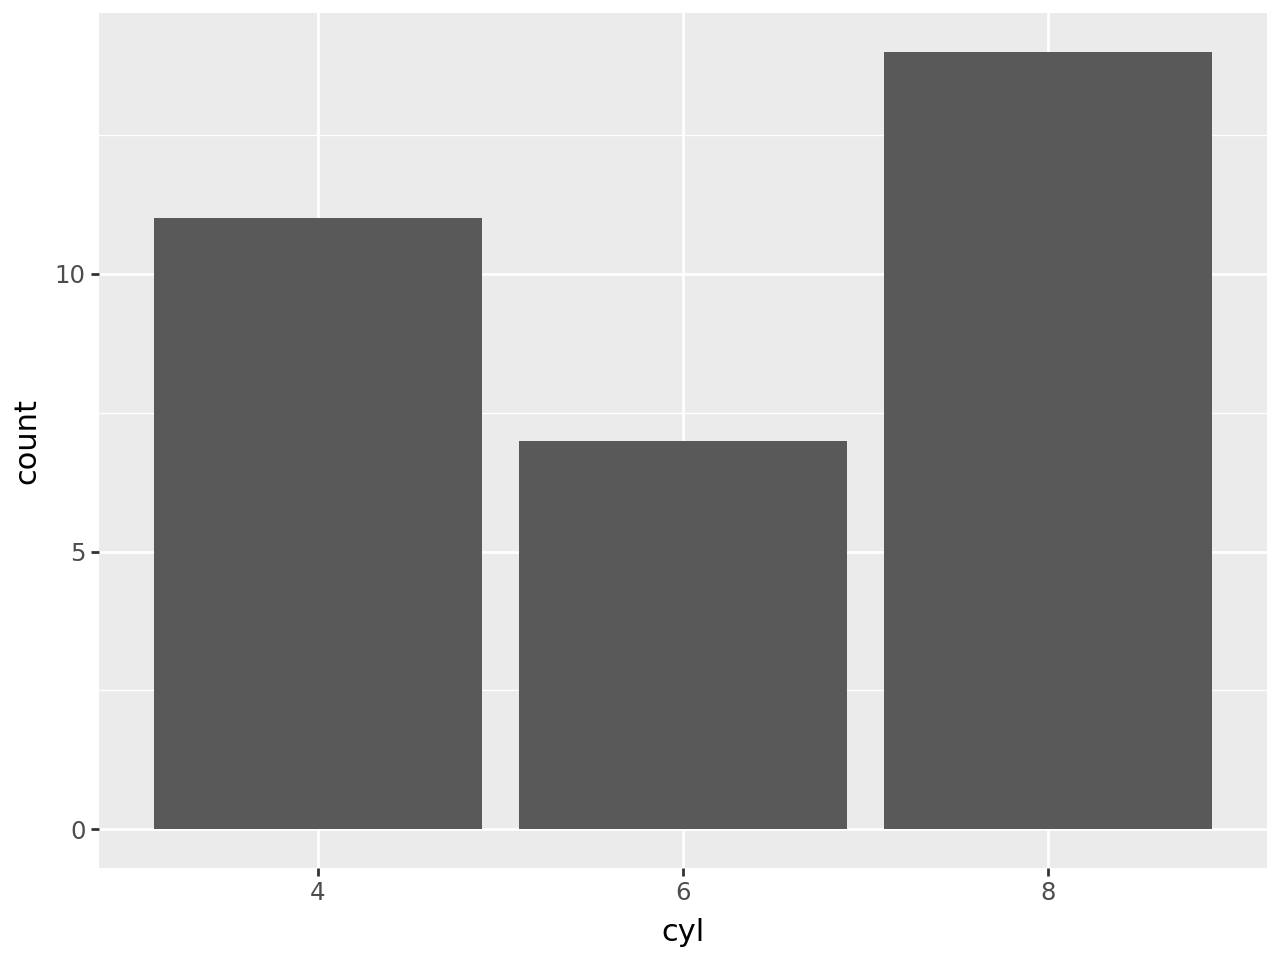

In [17]:
ggplot(mtcars, aes(x = "cyl")) + geom_bar()

Here's another example, this time from the diamonds dataset. Because ***color*** is already non-numeric, we do not need to apply the factor conversion to it.

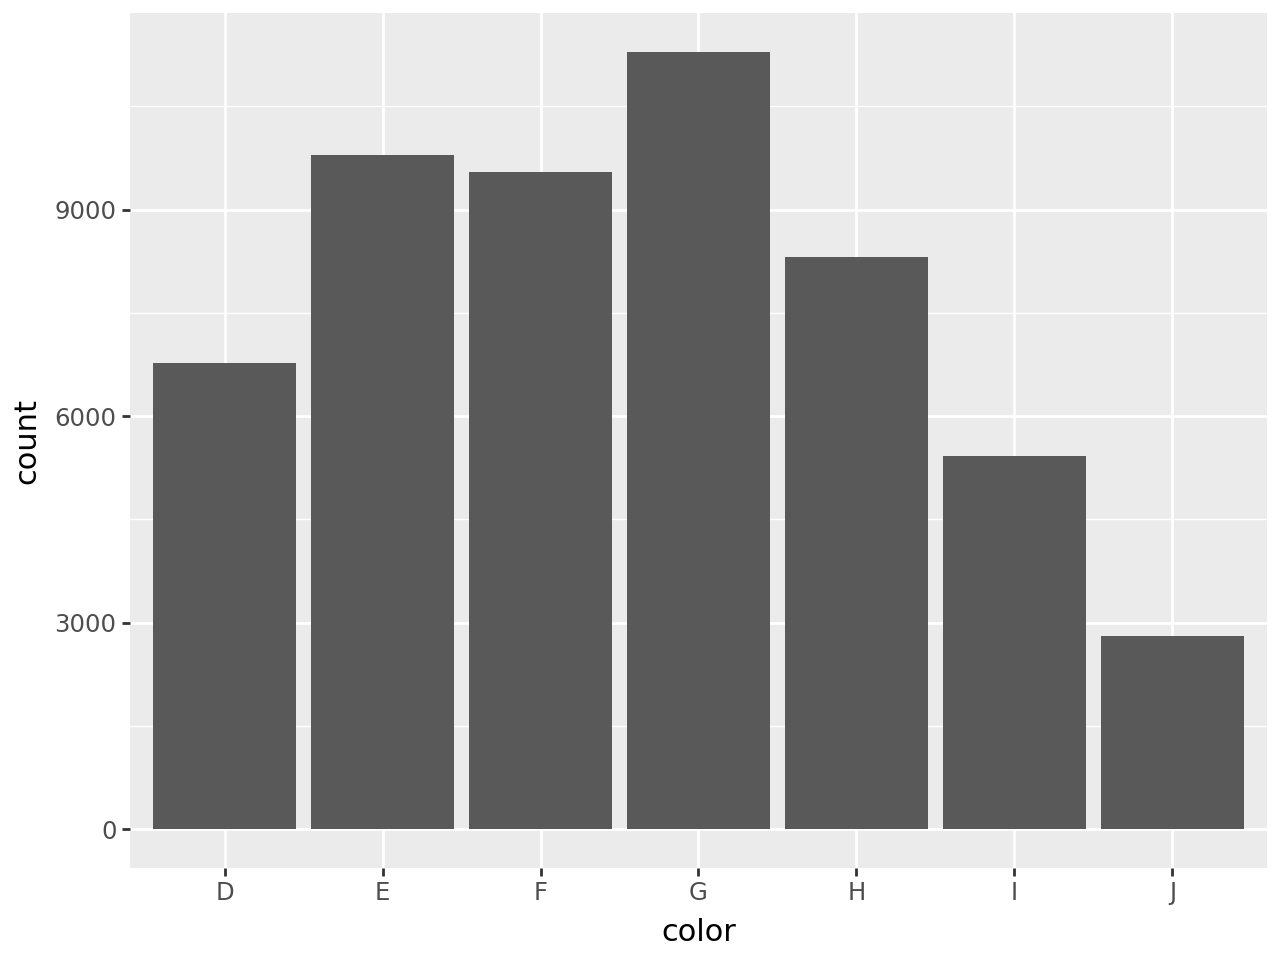

In [18]:
ggplot(diamonds, aes(x = "color")) + geom_bar()

⚡YOUR TURN: Create a bar chart from the ***iris*** data frame using ***species***.

⚡YOUR TURN: Create a bar chart from the ***diamonds*** data frame using ***cut***.

##Data Visualizations Using matplotlib

###Scatterplot
Next, we look at using the ***matplotlib*** library.  

The first code example is a simple scatterplot. Note how we define the variables (x is defined first, then y).

***plt.scatter():*** scatter is a function from the pyplot module in matplotlib library that creates a scatter plot. A scatter plot displays individual data points on a two-dimensional graph, where the x and y axes represent different variables.

***mtcars.hp:*** This refers to the hp (horsepower) variable from the mtcars dataset. It specifies the values to be plotted on the x-axis.

***mtcars.mpg:*** This refers to the mpg (miles per gallon) variable from the mtcars dataset. It specifies the values to be plotted on the y-axis.

It visually shows how the two variables relate to each other. This is a useful way to check if there is a pattern or correlation between hp and mpg.

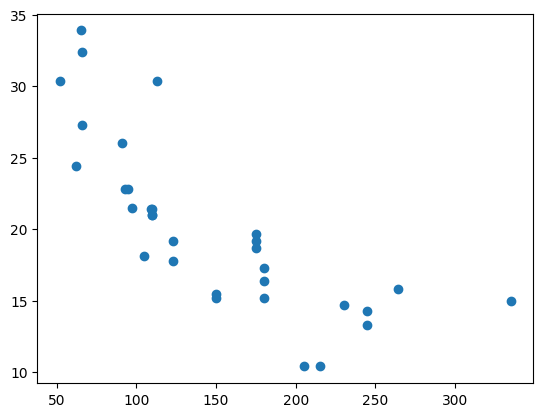

In [19]:
plt.scatter(mtcars.hp, mtcars.mpg)

For a complete plot, you would usually follow this line of code with additional code to label the axes and display the plot. This additional code sets axis labels and a title to make the plot more informative and calls plt.show() to display it.

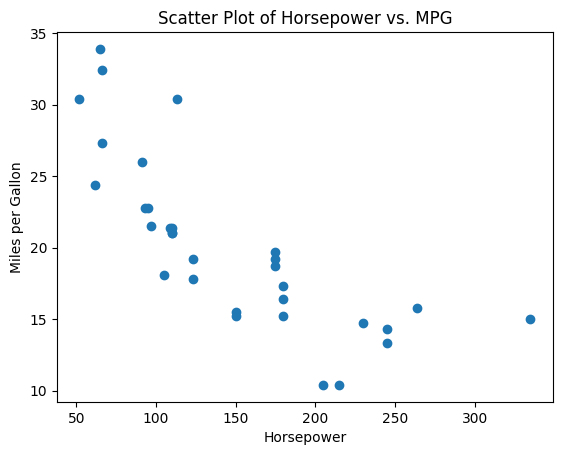

In [20]:
plt.scatter(mtcars.hp, mtcars.mpg)
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon")
plt.title("Scatter Plot of Horsepower vs. MPG")
plt.show()

In this example, we color the points by ***cyl***.

***c = mtcars.cyl:*** The parameter c is used to define the color of each data point. In this case, c is assigned to the cyl (number of cylinders) variable from the mtcars dataset. The scatter function automatically assigns different colors to data points based on the values in cyl, allowing you to visually differentiate between cars based on the number of cylinders.

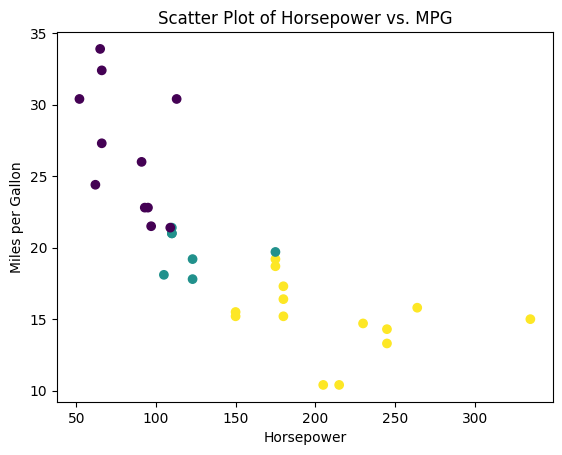

In [21]:
plt.scatter(mtcars.hp, mtcars.mpg, c = mtcars.cyl)
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon")
plt.title("Scatter Plot of Horsepower vs. MPG")
plt.show()

⚡YOUR TURN: Create a scatterplot from the ***diamonds*** data frame and use x = ***carat*** and y = ***price***

⚡YOUR TURN: Create a scatterplot from the ***iris*** data frame and use x = ***sepal_length*** and y = ***petal_length***.

###Boxplot

We start by looking at a simple boxplot of only ***mpg*** from the ***mtcars*** dataframe.  

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2b7b00f200>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2b7a001730>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2b7a018500>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2b7a000e30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2b7a003d70>],
 'means': []}

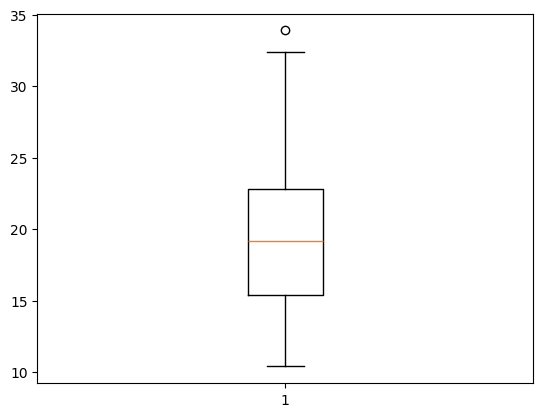

In [22]:
plt.boxplot(mtcars.mpg)

We can create a boxplot of ***mpg*** by ***cyl*** from the ***mtcars*** data frame.

<Axes: title={'center': 'mpg'}, xlabel='[cyl]'>

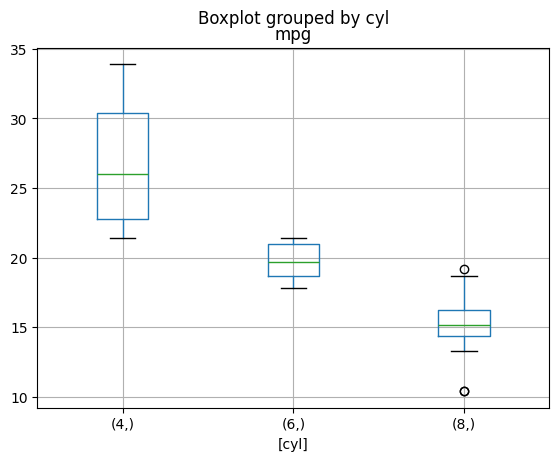

In [23]:
mtcars.boxplot(column=['mpg'], by=['cyl'])

⚡YOUR TURN: Create a boxplot from the ***iris*** data frame using ***petal_length***

⚡YOUR TURN: Create a boxplot from the ***iris*** data frame using ***petal_length*** by **species**

###Histogram

Let's create a histogram from the ***mtcars*** dataframe of the ***mpg*** variable.

(array([2., 4., 6., 6., 5., 3., 1., 1., 2., 2.]),
 array([10.4 , 12.75, 15.1 , 17.45, 19.8 , 22.15, 24.5 , 26.85, 29.2 ,
        31.55, 33.9 ]),
 <BarContainer object of 10 artists>)

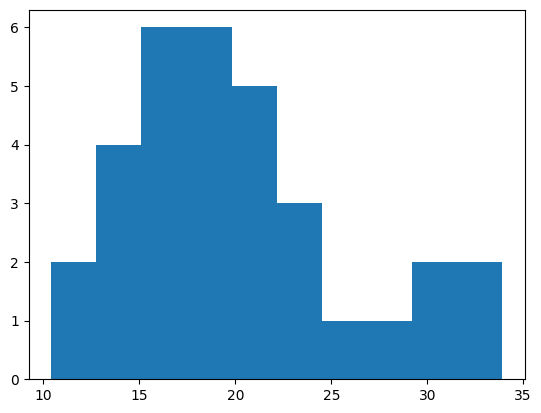

In [24]:
plt.hist(mtcars.mpg)

And another (this time from the diamonds dataset and the price variable) but let's specify we want the number of bins to equal 15. .

(array([20128.,  9062.,  5473.,  5561.,  3367.,  2343.,  1653.,  1325.,
         1131.,   895.,   782.,   631.,   598.,   527.,   464.]),
 array([  326.        ,  1559.13333333,  2792.26666667,  4025.4       ,
         5258.53333333,  6491.66666667,  7724.8       ,  8957.93333333,
        10191.06666667, 11424.2       , 12657.33333333, 13890.46666667,
        15123.6       , 16356.73333333, 17589.86666667, 18823.        ]),
 <BarContainer object of 15 artists>)

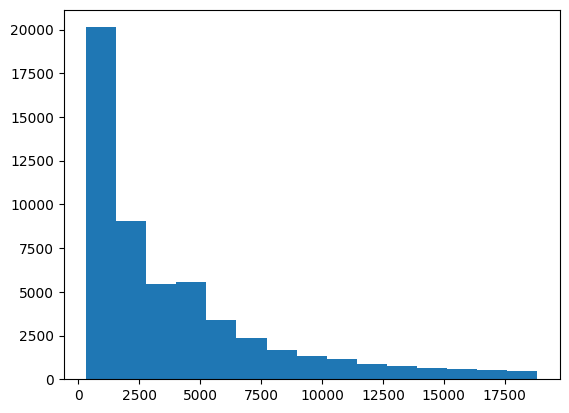

In [25]:
plt.hist(diamonds.price, bins = 15)

⚡YOUR TURN: Create a histogram from the ***iris*** data frame using ***sepal_length*** with bins = 10.

For comparison I have provided the plotnine (ggplot) code.

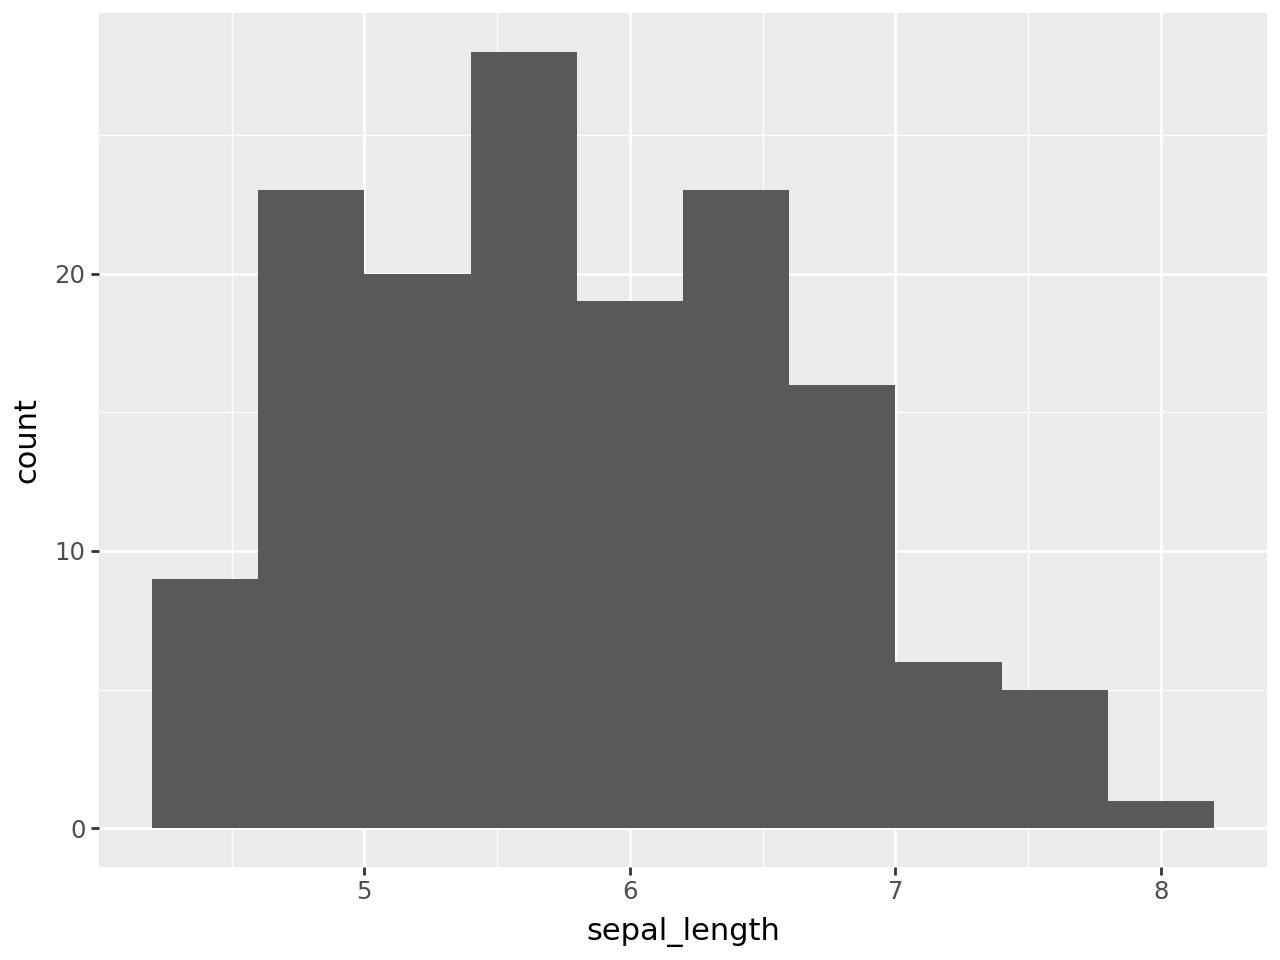

In [26]:
ggplot(iris, aes(x = "sepal_length")) + geom_histogram(bins = 10)

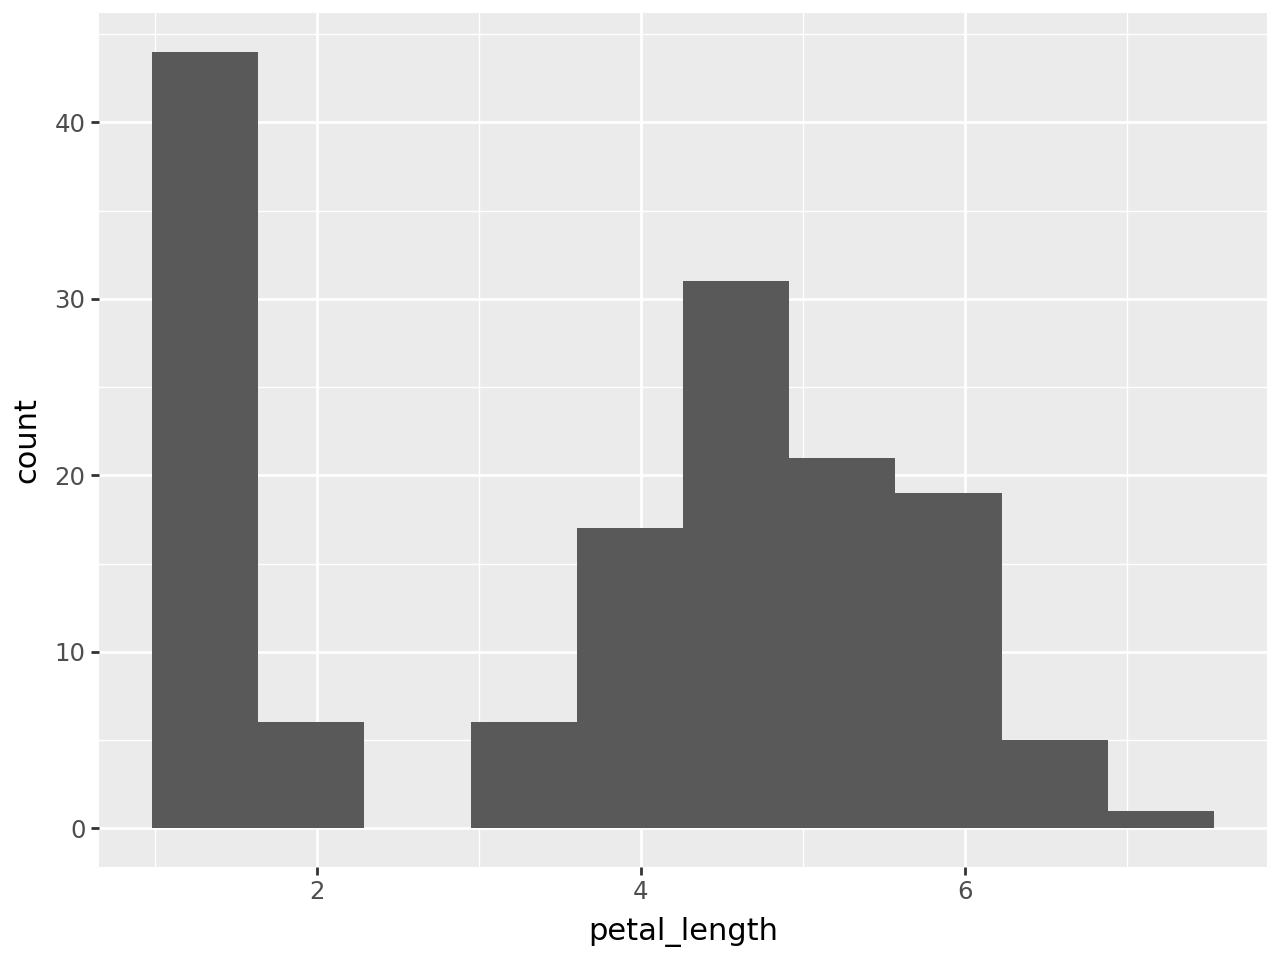

In [27]:
ggplot(iris, aes(x = "petal_length")) + geom_histogram(bins = 10)